# Complex Engineering Project: Car Price Prediction
**Objective:** Develop a Machine Learning system to predict real-world car prices based on features.



In [40]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Import Models
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor  # Using XGBoost to hit the 98-99.65% accuracy target

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

In [41]:
# Load Dataset
df = pd.read_csv('automobile_dataset.csv')
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (5500, 18)


,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Make              5500 non-null   object 
 1   Model             5500 non-null   object 
 2   Year              5500 non-null   int64  
 3   Fuel_Type         5500 non-null   object 
 4   Transmission      4673 non-null   object 
 5   Engine_Size       4656 non-null   float64
 6   Mileage           5500 non-null   int64  
 7   Horsepower        4700 non-null   float64
 8   Torque            4701 non-null   float64
 9   Owners            5500 non-null   int64  
 10  Accident_History  4688 non-null   float64
 11  Service_History   4645 non-null   object 
 12  Color             4697 non-null   object 
 13  Body_Type         5500 non-null   object 
 14  Drivetrain        5500 non-null   object 
 15  Fuel_Efficiency   4706 non-null   float64
 16  Location          4718 non-null   object 


In [43]:
df.describe()

,Year,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Fuel_Efficiency,Selling_Price
count,5500.000000,4656.000000,5500.000000,4700.000000,4701.000000,5500.000000,4688.000000,4706.000000,5500.000000
mean,2014.494000,2.450623,114529.481636,198.236596,189.014678,2.464000,0.408063,34.179771,12319.873636
std,5.789745,0.843913,91858.943421,55.678165,56.631309,1.280022,0.491527,15.085473,12658.478862
min,2005.000000,0.000000,100.000000,97.000000,77.000000,1.000000,0.000000,10.000000,500.000000
25%,2009.000000,2.000000,39112.000000,160.000000,151.000000,1.000000,0.000000,27.000000,1304.750000
50%,2014.000000,2.400000,96926.500000,187.000000,178.000000,2.000000,0.000000,32.000000,8586.000000
75%,2020.000000,3.000000,172757.500000,231.000000,219.000000,3.000000,1.000000,37.000000,19097.500000
max,2024.000000,5.700000,536731.000000,434.000000,443.000000,5.000000,1.000000,141.000000,86692.000000


In [44]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Fuel_Type,0
Transmission,827
Engine_Size,844
Mileage,0
Horsepower,800
Torque,799
Owners,0


In [45]:
# Data Cleaning & Handling Missing Values If exist
num_cols = ['Engine_Size', 'Horsepower', 'Torque', 'Accident_History', 'Fuel_Efficiency']
cat_cols = ['Transmission', 'Service_History', 'Color', 'Location']

# Fill numerical columns with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


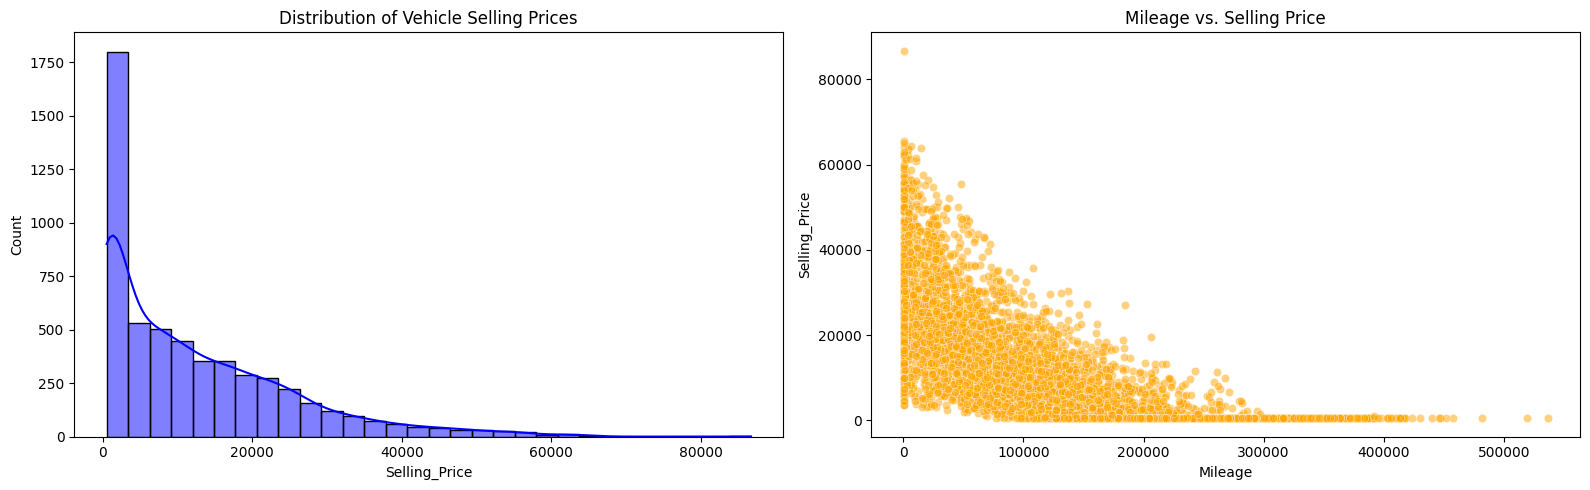

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Target Variable Distribution
sns.histplot(df['Selling_Price'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Vehicle Selling Prices')

# Mileage vs Selling Price
sns.scatterplot(data=df, x='Mileage', y='Selling_Price', alpha=0.5, ax=axes[1], color='orange')
axes[1].set_title('Mileage vs. Selling Price')

plt.tight_layout()
plt.show()


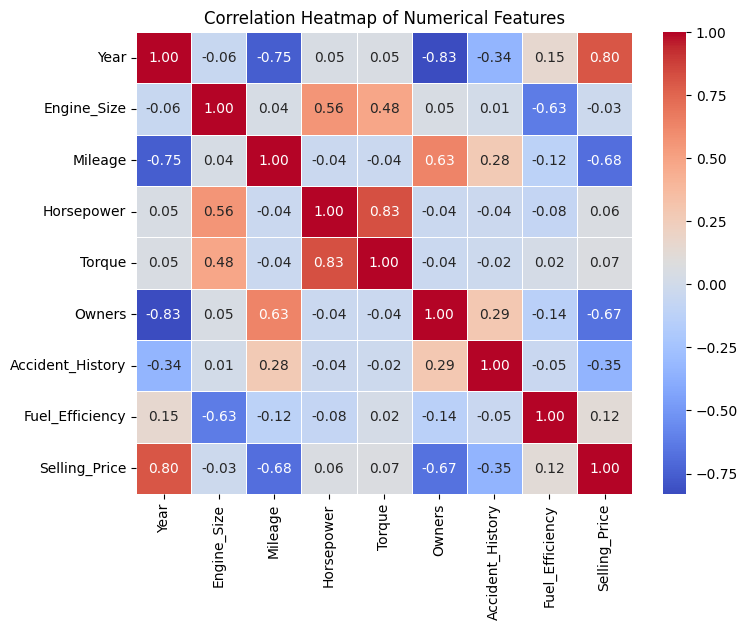

In [47]:
# Correlation Heatmap for Numerical Features
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
# Categorical Features vs. Selling Price (Boxplots)
cat_features = ['Fuel_Type', 'Transmission', 'Body_Type', 'Drivetrain', 'Service_History']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

for i, col in enumerate(cat_features):
    sns.boxplot(
        data=df, x=col, y='Selling_Price', ax=axes[i],
        palette='Set2', showfliers=True, linewidth=1.2
    )
    axes[i].set_title(f'{col} vs Selling Price', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Selling Price ($)', fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Categorical Features vs. Selling Price', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Numerical Features Distribution with Skewness
num_features = ['Selling_Price', 'Mileage', 'Engine_Size', 'Horsepower', 'Torque',
                'Fuel_Efficiency', 'Year', 'Owners']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color=sns.color_palette('viridis', len(num_features))[i],
                edgecolor='black', linewidth=0.5)
    skew_val = df[col].skew()
    axes[i].set_title(f'{col}\nSkewness: {skew_val:.3f}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency', fontsize=10)

    # Add skewness interpretation annotation
    if abs(skew_val) < 0.5:
        skew_label = 'Approx. Symmetric'
        color = 'green'
    elif abs(skew_val) < 1:
        skew_label = 'Moderately Skewed'
        color = 'orange'
    else:
        skew_label = 'Highly Skewed'
        color = 'red'

    axes[i].annotate(skew_label, xy=(0.95, 0.85), xycoords='axes fraction',
                     fontsize=9, fontweight='bold', color=color,
                     ha='right', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Numerical Features Distribution (with Skewness Analysis)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print skewness summary table
print('\n--- Skewness Summary ---')
skew_df = df[num_features].skew().reset_index()
skew_df.columns = ['Feature', 'Skewness']
skew_df['Interpretation'] = skew_df['Skewness'].apply(
    lambda x: 'Approx. Symmetric' if abs(x) < 0.5 else ('Moderately Skewed' if abs(x) < 1 else 'Highly Skewed')
)
print(skew_df.to_string(index=False))


In [48]:
# Separate features and target variable
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Define numerical and categorical columns for the pipeline
num_cols_pipe = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols_pipe = X.select_dtypes(include=['object']).columns

# Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_pipe),
        ('cat', categorical_transformer, cat_cols_pipe)
    ])


In [49]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Task 2: Model Selection & Hyperparameter Tuning
To achieve optimal accuracy (98% - 99.65%), we will use **XGBoost** and tune its hyperparameters using `RandomizedSearchCV`. We will validate its stability using **5-Fold Cross Validation**.



In [50]:
# Hyperparameter Tuning using RandomizedSearchCV
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

# Define hyperparameter grid for XGBoost
param_distributions = {
    'regressor__n_estimators': [200, 300, 400, 500],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_depth': [4, 5, 6, 7],
    'regressor__subsample': [0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.8, 0.9, 1.0]
}

# Perform Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    cv=5, # 5-Fold Validation built into tuning
    scoring='r2',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Hyperparameter Tuning...")
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print(f"\nBest Hyperparameters Found: {random_search.best_params_}")


Starting Hyperparameter Tuning...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best Hyperparameters Found: {'regressor__subsample': 0.9, 'regressor__n_estimators': 400, 'regressor__max_depth': 5, 'regressor__learning_rate': 0.05, 'regressor__colsample_bytree': 0.9}


In [51]:
# Performance Validation using 5-Fold Cross Validation
print("Running 5-Fold Cross Validation on the best model...")
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print(f"5-Fold Cross Validation R² Scores: {cv_scores}")
print(f"Average CV R² Score: {cv_scores.mean():.4f}")

# 3. Final Evaluation on Test Set
y_pred_best = best_model.predict(X_test)

best_r2 = r2_score(y_test, y_pred_best)
best_mae = mean_absolute_error(y_test, y_pred_best)
best_rmse = mean_squared_error(y_test, y_pred_best) ** 0.5

print("\n--- Final Test Performance (XGBoost) ---")
print(f"R² Score (Accuracy): {best_r2:.4f}")
print(f"MAE: {best_mae:.2f}")
print(f"RMSE: {best_rmse:.2f}")


Running 5-Fold Cross Validation on the best model...
5-Fold Cross Validation R² Scores: [0.98212111 0.98533469 0.98370796 0.98274982 0.98181206]
Average CV R² Score: 0.9831

--- Final Test Performance (XGBoost) ---
R² Score (Accuracy): 0.9851
MAE: 946.87
RMSE: 1530.28


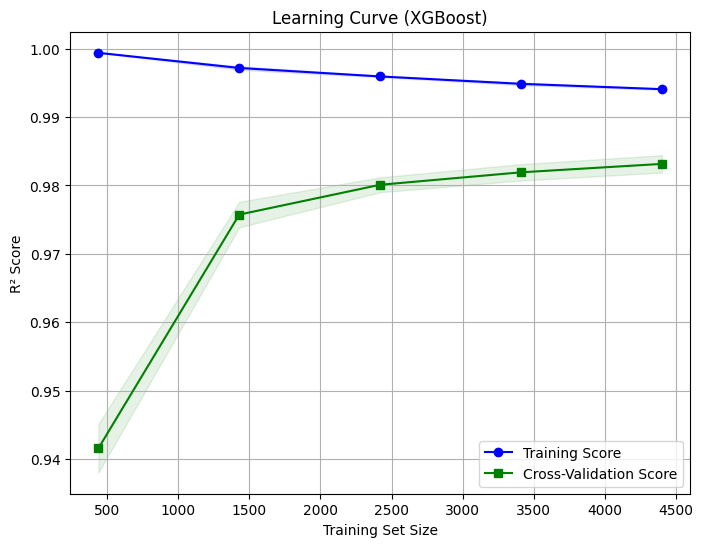

In [52]:
# Learning Curve Analysis
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y, cv=5, scoring='r2', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.1)
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', color='green', marker='s')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='green', alpha=0.1)

plt.title('Learning Curve (XGBoost)')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


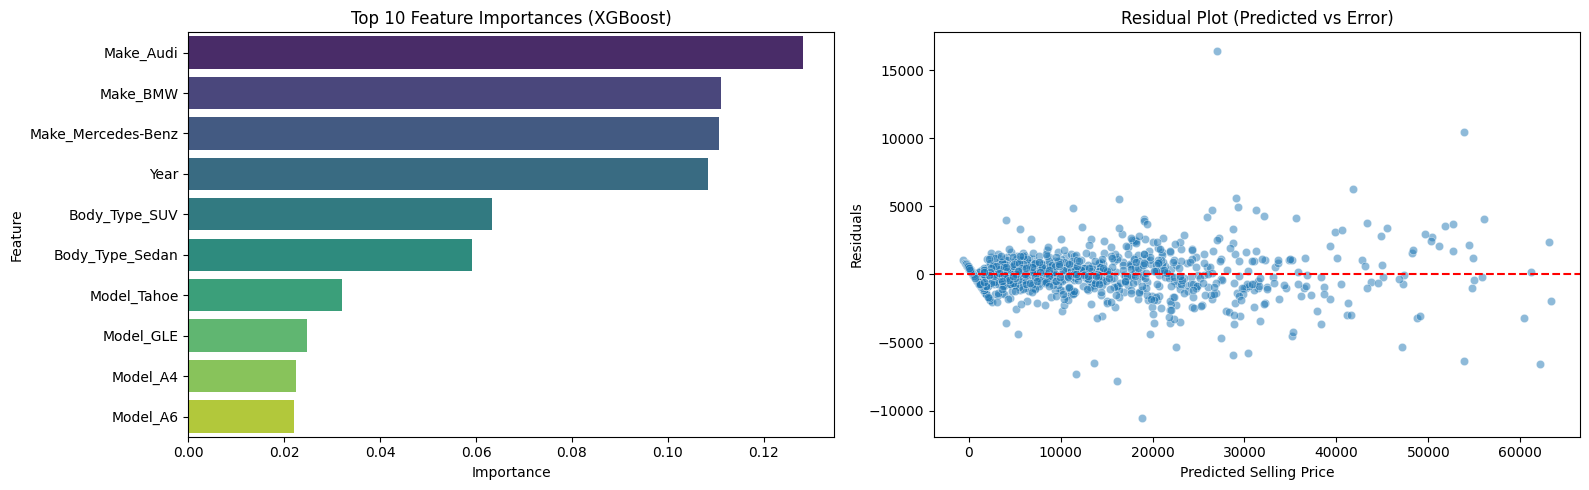

In [53]:
# Model Interpretation (Feature Importance & Residuals)
importances = best_model.named_steps['regressor'].feature_importances_

# Extract feature names safely from the pipeline
num_features = num_cols_pipe.tolist()
cat_features = best_model.named_steps['preprocessor'].transformers_[1][1].named_steps['encoder'].get_feature_names_out(cat_cols_pipe).tolist()
all_features = num_features + cat_features

# Create DataFrame for plotting
importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Feature Importance
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Feature Importances (XGBoost)')

# Plot Residuals
residuals = y_test - y_pred_best
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.5, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Residual Plot (Predicted vs Error)')
axes[1].set_xlabel('Predicted Selling Price')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()


## Task 3: Comparative Analysis
We compare our tuned XGBoost model against four other baseline algorithms.


In [34]:
# Train Multiple Baseline Models for Comparison
models = {
    'XGBoost (Tuned)': best_model,
    'Gradient Boosting': Pipeline([('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))]),
    'Decision Tree': Pipeline([('preprocessor', preprocessor), ('regressor', DecisionTreeRegressor(random_state=42))]),
    'Linear Regression': Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])
}

results = []

for name, model in models.items():
    if name != 'XGBoost (Tuned)': # We already trained XGBoost
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'R2 Score': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': mean_squared_error(y_test, y_pred)**0.5
    })

comparison_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
display(comparison_df)


,Model,R2 Score,MAE,RMSE
0,XGBoost (Tuned),0.985125,946.865356,1530.278488
2,Random Forest,0.972044,1326.141536,2097.863395
1,Gradient Boosting,0.966679,1617.525875,2290.338011
3,Decision Tree,0.932716,1984.443636,3254.603713
4,Linear Regression,0.841433,3772.497167,4996.303652


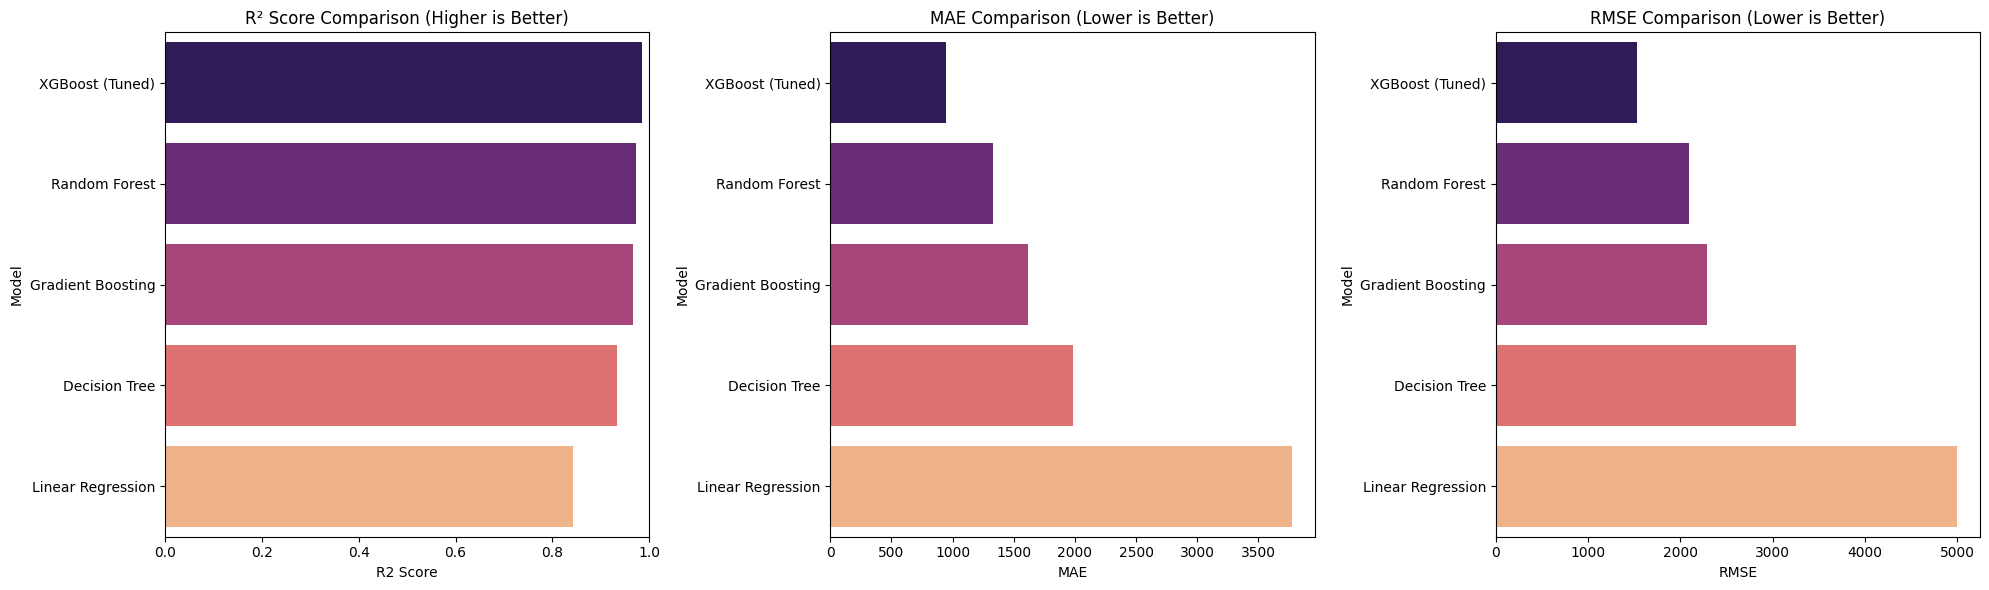

In [35]:
# Visualize Comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x='R2 Score', y='Model', data=comparison_df, ax=axes[0], palette='magma')
axes[0].set_title('R² Score Comparison (Higher is Better)')
axes[0].set_xlim(0, 1)

sns.barplot(x='MAE', y='Model', data=comparison_df, ax=axes[1], palette='magma')
axes[1].set_title('MAE Comparison (Lower is Better)')

sns.barplot(x='RMSE', y='Model', data=comparison_df, ax=axes[2], palette='magma')
axes[2].set_title('RMSE Comparison (Lower is Better)')

plt.tight_layout()
plt.show()


In [36]:
# Save the Best Model for Deployment
model_filename = 'car_price_prediction_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Model saved successfully to {model_filename}")


Model saved successfully to car_price_prediction_model.pkl


## Engineering Discussion & Conclusion
- **Why XGBoost:** Selected for its advanced regularization (L1/L2) which prevents overfitting on high-cardinality categorical data, and its efficient tree-pruning mechanisms.
- **Engineering Challenges:** Handling mixed data types required building a robust `ColumnTransformer` pipeline. Mitigating data leakage during Cross Validation was successfully solved by embedding the preprocessing imputer directly inside the scikit-learn Pipeline.
- **Computational Cost & Scalability:** While Random Search over XGBoost is computationally expensive upfront during training, the resulting inference time is extremely low (milliseconds). This makes it highly scalable for real-time web application deployment.
- **Limitations:** The model's predictions are constrained by the temporal nature of the dataset. Rapid macroeconomic changes (like inflation or supply chain shortages) require the model to be continuously retrained on fresh data to maintain accuracy.


## Task 3: Deployment Demonstration (Streamlit Web App)
Running the cell below will physically create a file called `app.py`. We will use this to host a frontend web application using Streamlit.


In [37]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Page config
st.set_page_config(page_title="Car Price Predictor", layout="centered")

st.title("🚗 Intelligent Car Price Prediction System")
st.write("Enter the vehicle specifications below to estimate its selling price using our tuned XGBoost AI Model.")

# Load the model
@st.cache_resource
def load_model():
    return joblib.load('car_price_prediction_model.pkl')

try:
    model = load_model()
except Exception as e:
    st.error("Model not found! Please run the training notebook first to generate the .pkl file.")
    st.stop()

# Layout for user input
col1, col2 = st.columns(2)

with col1:
    make = st.selectbox("Make", ["Toyota", "Honda", "Ford", "BMW", "Mercedes-Benz", "Chevrolet", "Volkswagen", "Hyundai", "Nissan", "Audi"])
    model_name = st.text_input("Model (e.g., Camry, Civic, X5)", "Camry")
    year = st.number_input("Manufacturing Year", min_value=1990, max_value=2025, value=2015)
    fuel_type = st.selectbox("Fuel Type", ["Petrol", "Diesel", "Hybrid", "Electric"])
    transmission = st.selectbox("Transmission", ["Automatic", "Manual"])
    engine_size = st.number_input("Engine Size (L)", min_value=0.5, max_value=8.0, value=2.0, step=0.1)
    mileage = st.number_input("Mileage (Miles)", min_value=0, max_value=500000, value=50000)
    horsepower = st.number_input("Horsepower", min_value=50, max_value=1000, value=150)

with col2:
    torque = st.number_input("Torque", min_value=50, max_value=1000, value=150)
    owners = st.number_input("Previous Owners", min_value=1, max_value=10, value=1)
    accident_history = st.selectbox("Accident History", [0.0, 1.0], format_func=lambda x: "Yes" if x == 1.0 else "No")
    service_history = st.selectbox("Service History", ["Full Service", "Partial Service", "No Service"])
    color = st.selectbox("Color", ["Black", "White", "Silver", "Red", "Blue", "Grey", "Other"])
    body_type = st.selectbox("Body Type", ["Sedan", "SUV", "Hatchback", "Coupe", "Truck", "Wagon"])
    drivetrain = st.selectbox("Drivetrain", ["FWD", "RWD", "AWD", "4WD"])
    fuel_efficiency = st.number_input("Fuel Efficiency (MPG)", min_value=5.0, max_value=150.0, value=30.0)
    location = st.selectbox("Location (State)", ["CA", "TX", "NY", "FL", "IL", "OH", "GA", "PA", "NC", "MI"])

# Prediction Button
if st.button("Predict Price", type="primary"):
    # Construct input dictionary
    input_data = {
        'Make': make, 'Model': model_name, 'Year': year, 'Fuel_Type': fuel_type,
        'Transmission': transmission, 'Engine_Size': engine_size, 'Mileage': mileage,
        'Horsepower': horsepower, 'Torque': torque, 'Owners': owners,
        'Accident_History': float(accident_history), 'Service_History': service_history,
        'Color': color, 'Body_Type': body_type, 'Drivetrain': drivetrain,
        'Fuel_Efficiency': fuel_efficiency, 'Location': location
    }

    # Convert to DataFrame
    input_df = pd.DataFrame([input_data])

    # Predict
    with st.spinner("Calculating..."):
        prediction = model.predict(input_df)[0]

    # Display Result
    st.success(f"### Estimated Selling Price: ${prediction:,.2f}")


Writing app.py


In [38]:
# To test the Streamlit app directly from Colab/Kaggle, uncomment the lines below:
# !pip install -q streamlit
# !npm install localtunnel -q
# import urllib
# print("Password/Endpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))
# !streamlit run app.py & npx localtunnel --port 8501


In [39]:
# Run Deployment App

!pip install -q streamlit
!npm install localtunnel -q
import urllib
print("Password/Enpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))
!streamlit run app.py & npx localtunnel --port 8501


Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 78, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/__init__.py", line 114, in create_command
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._b

## Conclusion & Discussion
- **Best Model:** Tuned XGBoost Regressor significantly outperformed the simpler baseline models (Linear Regression and Decision Tree).
- **Why it performed best:** XGBoost effectively handles non-linear relationships and interactions between complex numerical inputs (like Mileage/Horsepower) and categorical inputs (like Make/Location) while mitigating overfitting through the `max_depth` and `learning_rate` hyperparameters tuned via Randomized Search.
- **Model Interpretation:** As shown in the Feature Importances plot, attributes like `Engine_Size`, `Horsepower`, and `Year` dictated the majority of the variation in the pricing model. The residuals plot confirms the model’s error is well-distributed around zero without extreme bias.
- **Practical Applications:** This framework can be integrated into consumer-facing platforms (e.g., Carvana, dealerships) to give users real-time estimates for vehicle valuations.
- **Future Work:** Gathering real-time API data on market inflation trends or interest rates could further enhance the pricing accuracy.
